In [2]:
import sys
from pathlib import Path
import pandas as pd

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    # Update if your repo lives somewhere else in Drive
    REPO_ROOT = Path("/content/drive/Shareddrives/CMPE 295A_B/subset")

else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT.name != "masters-project" and REPO_ROOT.parent != REPO_ROOT:
        REPO_ROOT = REPO_ROOT.parent

    if REPO_ROOT.name != "masters-project":
        raise RuntimeError("Could not find repo root folder named 'masters-project'.")

# Common paths
DATA_RAW = REPO_ROOT / "data" / "raw"
DATA_PROCESSED = REPO_ROOT / "data" / "processed"
INGEST_DIR = DATA_PROCESSED / "ingest_v0"

DOCS_DIR = REPO_ROOT / "docs"/"planning"
NOTEBOOK_DIR = REPO_ROOT / "notebooks" / "subset"

# reports/eval/subset structure
REPORTS_DIR = REPO_ROOT / "reports"
REPORTS_EVAL = REPORTS_DIR / "eval"
SUBSET_EVAL_DIR = REPORTS_EVAL / "subset"

FIG_DIR = SUBSET_EVAL_DIR / "figures"
TABLE_DIR = SUBSET_EVAL_DIR / "tables"
CACHE_DIR = SUBSET_EVAL_DIR / "cache"
LOG_DIR = SUBSET_EVAL_DIR / "logs"

# Optional: keep sanity summaries inside subset eval too
SANITY_DIR = SUBSET_EVAL_DIR / "sanity"

# Create folders
for p in [
    DATA_RAW,
    DATA_PROCESSED,
    INGEST_DIR,
    DOCS_DIR,
    NOTEBOOK_DIR,
    REPORTS_DIR,
    REPORTS_EVAL,
    SUBSET_EVAL_DIR,
    FIG_DIR,
    TABLE_DIR,
    CACHE_DIR,
    LOG_DIR,
    SANITY_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

# Input paths
SUBSET_RAW_DIR = DATA_RAW / "subset"
SUBSET_RAW_DIR.mkdir(parents=True, exist_ok=True)

# Choose the right CSV path for the setup
if IN_COLAB:
    # If CSV is in the repo under data/raw/subset
    SUBSET_CSV_PATH = SUBSET_RAW_DIR / "borg_traces_data.csv"
else:
    # Try repo-standard location first
    candidate1 = SUBSET_RAW_DIR / "borg_traces_data.csv"
    # Fallback to top-level subset folder if that's where the file is
    candidate2 = REPO_ROOT / "subset" / "borg_traces_data.csv"

    if candidate1.exists():
        SUBSET_CSV_PATH = candidate1
    else:
        SUBSET_CSV_PATH = candidate2

# Output paths
INGEST_PARQUET_PATH = INGEST_DIR / "subset_clean.parquet"
JOB_EXEC_PATH = DATA_PROCESSED / "job_exec_v0.parquet"
JOB_METRICS_PATH = DATA_PROCESSED / "job_metrics_v0.parquet"
INGEST_SUMMARY_PATH = SANITY_DIR / "ingest_summary.md"
RUNTIME_SUMMARY_PATH = SANITY_DIR / "runtime_summary.md"
SLACK_SUMMARY_PATH = SANITY_DIR / "slack_summary.md"
ASSUMPTIONS_PATH = DOCS_DIR / "assumptions2.md"

# Debug prints
print("Repo root:", REPO_ROOT)
print("Running in Colab:", IN_COLAB)
print("Subset CSV path:", SUBSET_CSV_PATH)
print("Processed dir:", DATA_PROCESSED)
print("Subset eval dir:", SUBSET_EVAL_DIR)
print("Figures dir:", FIG_DIR)
print("Tables dir:", TABLE_DIR)

# Load dataset
df = pd.read_csv(SUBSET_CSV_PATH, low_memory=False, nrows=100000)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(df.head())

Repo root: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project
Running in Colab: False
Subset CSV path: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/raw/subset/borg_traces_data.csv
Processed dir: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed
Subset eval dir: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/reports/eval/subset
Figures dir: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/reports/eval/subset/figures
Tables dir: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/reports/eval/subset/tables


,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,resource_request,constraint,collections_events_type,user,collection_name,collection_logical_name,start_after_collection_ids,vertical_scaling,scheduler,start_time,end_time,average_usage,maximum_usage,random_sample_usage,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,"{'cpus': 0.020660400390625, 'memory': 0.014434...",[],2,fn8Ve4Tdl/FVVvwXFGIKe4+Wo4zLjUL/557qdFVYu5M=,Hzsv/gF8CPQXdqpsfovDTC1TJNyphDxPu7vaTeNxA74=,YCuhYrnORLiUh9WGL5q5tkBevfwtucSnFr2qPZh6Kes=,[],1.0,0.0,274800000000,275100000000,"{'cpus': 0.00466156005859375, 'memory': 0.0059...","{'cpus': 0.01190185546875, 'memory': 0.0059356...","{'cpus': 0.0043487548828125, 'memory': None}",0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,"{'cpus': 0.00724029541015625, 'memory': 0.0013...",[],2,DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=,hDGffcrF/rhQQEG8Uns/RMUK7R15DXjFnRasoKFhefI=,wcRcAMuop2OqH9EW4feH919tadFec5a11ply0hcS/C8=,[],2.0,0.0,1800713000000,1800714000000,"{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': 9.5367431640625e-07}","{'cpus': 0.0, 'memory': None}",0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,"{'cpus': 0.048583984375, 'memory': 0.004165649...",[],6,/ivQBmewiFcXfGJdCUsEKx47NiRE29Tjiq3gw+zR2Cg=,kk6+maA6fvAdJ+VTU8AcpzQPTyVrx+ySt0MXRAyO8FU=,zCA2dl2PDptd82Hob906gE82JHzx0SbqA4mZurqZdmY=,[],2.0,1.0,81300000000,81600000000,"{'cpus': 0.024200439453125, 'memory': 0.002788...","{'cpus': 0.06005859375, 'memory': 0.0028457641...","{'cpus': 0.026458740234375, 'memory': None}",0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,"{'cpus': 0.0704345703125, 'memory': 0.04162597...",[],2,8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=,fypwFjdqaQPSxCfeqVPCBAvFcnntmkRpQxwQ/vJsCxU=,uNjMQD1+DL9IgCFckx8lHOsCbyvLgKmZCmRjiyWZNhk=,[],2.0,0.0,1075500000000,1075800000000,"{'cpus': 0.047607421875, 'memory': 0.034423828...","{'cpus': 0.13330078125, 'memory': 0.03466796875}","{'cpus': 0.05084228515625, 'memory': None}",0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,"{'cpus': 0.00244903564453125, 'memory': 0.0002...",[],3,+cz+wEXttqDjld+YWLmrgqExjdqiHMZ2WZODThyR9jE=,WS2kraTQdfsFtOIepw9SIo7ETi2ag8uwy7gt2MrpIe0=,VJ0ExwthLLpbqbyOA77EoNypzEiPYg3mECxUve0GCnY=,[],3.0,0.0,1565315000000,1565317000000,"{'cpus': 0.000270843505859375, 'memory': 7.629...","{'cpus': 0.00041484832763671875, 'memory': 7.6...","{'cpus': 0.0003414154052734375, 'memory': None}",0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [3]:
# Total rows
row_count = sum(1 for _ in open(SUBSET_CSV_PATH)) - 1
# Total columns
df_sample = pd.read_csv(SUBSET_CSV_PATH, nrows=1)
col_count = len(df_sample.columns)
print(f"Dataset size: {row_count} rows × {col_count} columns")
cols = df.columns.tolist()
print(cols)

Dataset size: 1324694 rows × 34 columns
['Unnamed: 0', 'time', 'instance_events_type', 'collection_id', 'scheduling_class', 'collection_type', 'priority', 'alloc_collection_id', 'instance_index', 'machine_id', 'resource_request', 'constraint', 'collections_events_type', 'user', 'collection_name', 'collection_logical_name', 'start_after_collection_ids', 'vertical_scaling', 'scheduler', 'start_time', 'end_time', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction', 'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster', 'event', 'failed']


In [4]:
for i in range(3):
    print(f"\nRow {i}:")
    for col, val in df.iloc[i].items():
        print(f"{col} → {val}")


Row 0:
Unnamed: 0 → 0
time → 0
instance_events_type → 2
collection_id → 94591244395
scheduling_class → 3
collection_type → 1
priority → 200
alloc_collection_id → 0
instance_index → 144
machine_id → 168846390496
resource_request → {'cpus': 0.020660400390625, 'memory': 0.014434814453125}
constraint → []
collections_events_type → 2
user → fn8Ve4Tdl/FVVvwXFGIKe4+Wo4zLjUL/557qdFVYu5M=
collection_name → Hzsv/gF8CPQXdqpsfovDTC1TJNyphDxPu7vaTeNxA74=
collection_logical_name → YCuhYrnORLiUh9WGL5q5tkBevfwtucSnFr2qPZh6Kes=
start_after_collection_ids → []
vertical_scaling → 1.0
scheduler → 0.0
start_time → 274800000000
end_time → 275100000000
average_usage → {'cpus': 0.00466156005859375, 'memory': 0.00592041015625}
maximum_usage → {'cpus': 0.01190185546875, 'memory': 0.0059356689453125}
random_sample_usage → {'cpus': 0.0043487548828125, 'memory': None}
assigned_memory → 0.014434814453125
page_cache_memory → 0.0004148483276367
cycles_per_instruction → nan
memory_accesses_per_instruction → nan
sampl

In [5]:
#Column meaning + what maps to TraceAdvisor fields
cols = [c.lower() for c in df.columns]
keywords = ["job", "task", "time", "start", "end", "submit", "cpu", "mem", "memory", "gpu", "request", "usage"]
for k in keywords:
    matches = [c for c in df.columns if k in c.lower()]
    if matches:
        print(k, "->", matches[:20])

time -> ['time', 'start_time', 'end_time']
start -> ['start_after_collection_ids', 'start_time']
end -> ['end_time']
cpu -> ['cpu_usage_distribution', 'tail_cpu_usage_distribution']
mem -> ['assigned_memory', 'page_cache_memory', 'memory_accesses_per_instruction']
memory -> ['assigned_memory', 'page_cache_memory', 'memory_accesses_per_instruction']
request -> ['resource_request']
usage -> ['average_usage', 'maximum_usage', 'random_sample_usage', 'cpu_usage_distribution', 'tail_cpu_usage_distribution']


In [6]:
# Missingness + basic stats
missing = df.isna().mean().sort_values(ascending=False)
display(missing.head(30))

display(df.describe(include="all").transpose().head(30))

memory_accesses_per_instruction    0.30676
cycles_per_instruction             0.30676
vertical_scaling                   0.00231
scheduler                          0.00231
resource_request                   0.00195
Unnamed: 0                         0.00000
time                               0.00000
priority                           0.00000
instance_events_type               0.00000
collection_id                      0.00000
machine_id                         0.00000
instance_index                     0.00000
collections_events_type            0.00000
constraint                         0.00000
user                               0.00000
alloc_collection_id                0.00000
scheduling_class                   0.00000
collection_type                    0.00000
start_after_collection_ids         0.00000
collection_logical_name            0.00000
collection_name                    0.00000
start_time                         0.00000
maximum_usage                      0.00000
random_samp

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,100000.0,NaN,NaN,NaN,49999.5,28867.657797,0.0,24999.75,49999.5,74999.25,99999.0
time,100000.0,NaN,NaN,NaN,93340701812771.84375,29166859854785512.0,0.0,267739888953.25,1088061792501.0,1768873541353.5,9223372036854775808.0
instance_events_type,100000.0,NaN,NaN,NaN,2.94589,2.046891,0.0,2.0,3.0,5.0,9.0
collection_id,100000.0,NaN,NaN,NaN,358391063262.12854,244414259099.983429,6824.0,212549588690.0,310582627588.0,491881218800.0,824867707812.0
scheduling_class,100000.0,NaN,NaN,NaN,1.26851,1.015028,0.0,0.0,1.0,2.0,3.0
collection_type,100000.0,NaN,NaN,NaN,0.08807,0.283398,0.0,0.0,0.0,0.0,1.0
priority,100000.0,NaN,NaN,NaN,147.71053,116.538504,0.0,103.0,105.0,200.0,450.0
alloc_collection_id,100000.0,NaN,NaN,NaN,69796755026.195038,166671916888.882568,0.0,0.0,0.0,0.0,742666686475.0
instance_index,100000.0,NaN,NaN,NaN,5056.54374,11886.795007,0.0,401.0,1375.0,4241.0,177107.0
machine_id,100000.0,NaN,NaN,NaN,84498258794.465149,136846298207.328201,-1.0,2931684445.5,20143057309.0,128372963509.25,825427385411.0


In [7]:
# Check if requested and peak-used fields are present
req_cols = [c for c in df.columns if "req" in c.lower() or "request" in c.lower()]
usage_cols = [c for c in df.columns if "usage" in c.lower() or "util" in c.lower()]
print("Request candidates:", req_cols[:30])
print("Usage candidates:", usage_cols[:30])

Request candidates: ['resource_request']
Usage candidates: ['average_usage', 'maximum_usage', 'random_sample_usage', 'cpu_usage_distribution', 'tail_cpu_usage_distribution']


In [8]:
# Inspect the nested usage fields
import ast
def to_dict(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return None
    return None

for col in ["resource_request", "maximum_usage", "average_usage", "random_sample_usage"]:
    print(col, "type:", type(df[col].iloc[0]))
    print(df[col].iloc[0])
    print("----")

resource_request type: <class 'str'>
{'cpus': 0.020660400390625, 'memory': 0.014434814453125}
----
maximum_usage type: <class 'str'>
{'cpus': 0.01190185546875, 'memory': 0.0059356689453125}
----
average_usage type: <class 'str'>
{'cpus': 0.00466156005859375, 'memory': 0.00592041015625}
----
random_sample_usage type: <class 'str'>
{'cpus': 0.0043487548828125, 'memory': None}
----


In [9]:
# Parse + flatten into numeric columns
import ast
import numpy as np
import pandas as pd

def parse_dict(s):
    if pd.isna(s):
        return {}
    if isinstance(s, dict):
        return s
    try:
        return ast.literal_eval(s)
    except Exception:
        return {}

# Parse dict-like columns
df["rr"]   = df["resource_request"].apply(parse_dict)
df["maxu"] = df["maximum_usage"].apply(parse_dict)
df["avgu"] = df["average_usage"].apply(parse_dict)
df["rsu"]  = df["random_sample_usage"].apply(parse_dict)

# Extract request + usage
df["req_cpu"]  = df["rr"].apply(lambda d: d.get("cpus"))
df["req_mem"]  = df["rr"].apply(lambda d: d.get("memory"))

df["peak_cpu"] = df["maxu"].apply(lambda d: d.get("cpus"))
df["peak_mem"] = df["maxu"].apply(lambda d: d.get("memory"))

df["avg_cpu"]  = df["avgu"].apply(lambda d: d.get("cpus"))
df["avg_mem"]  = df["avgu"].apply(lambda d: d.get("memory"))

# Optional (not needed for baseline v0): sample usage
df["sample_cpu"] = df["rsu"].apply(lambda d: d.get("cpus"))
df["sample_mem"] = df["rsu"].apply(lambda d: d.get("memory"))

df[["req_cpu","req_mem","peak_cpu","peak_mem","avg_cpu","avg_mem"]].head()

,req_cpu,req_mem,peak_cpu,peak_mem,avg_cpu,avg_mem
0,0.020660,0.014435,0.011902,5.935669e-03,0.004662,5.920410e-03
1,0.007240,0.001303,0.000000,9.536743e-07,0.000000,9.536743e-07
2,0.048584,0.004166,0.060059,2.845764e-03,0.024200,2.788544e-03
3,0.070435,0.041626,0.133301,3.466797e-02,0.047607,3.442383e-02
4,0.002449,0.000232,0.000415,7.629395e-05,0.000271,7.629395e-05


In [10]:
# Unit normalization
CPU_TO_CORES = 1.0   # change if raw CPU is in millicores
MEM_TO_GB = 1.0      # change if raw memory is in MB

for col in ["req_cpu", "avg_cpu", "peak_cpu"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce") * CPU_TO_CORES

for col in ["req_mem", "avg_mem", "peak_mem"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce") * MEM_TO_GB

print("Normalization done.")

Normalization done.


In [11]:
# Sanity-check missingness:
df[["req_cpu","req_mem","peak_cpu","peak_mem","avg_cpu","avg_mem"]].isna().mean().sort_values(ascending=False)

peak_mem    0.01204
req_cpu     0.00195
req_mem     0.00195
peak_cpu    0.00000
avg_cpu     0.00000
avg_mem     0.00000
dtype: float64

In [12]:
# Define IDs for execution + recurring job
df["execution_id"] = df["collection_id"].astype(str) + "_" + df["instance_index"].astype(str)

# Define recurrence key: (user,collection_logical_name)
df["logical_name"] = df["collection_logical_name"].fillna(df["collection_name"])
df["user_clean"] = df["user"].fillna("unknown_user").astype(str)
df["logical_name"] = df["logical_name"].fillna("unknown_job").astype(str)
df["recurrence_key"] = df["user_clean"] + "||" + df["logical_name"]
df["recurring_job_id"] = df["recurrence_key"]

# Check recurrence counts:
df["recurring_job_id"].value_counts().head(20)

recurring_job_id
DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=||mOIaNf8mXWKMT1ODsgfz3yhpFBedgNmcMaskvu55SBc=    12052
DrrEIEWkWuW7RrZwpHLCN0k0A2J0usJeyt3wtqzZ7Kk=||wcRcAMuop2OqH9EW4feH919tadFec5a11ply0hcS/C8=     4850
+cz+wEXttqDjld+YWLmrgqExjdqiHMZ2WZODThyR9jE=||ie5iGahM0adHFVwiIPBS9clQiQ0SrDQhN8bgC3FIUuI=     4281
DHJYL1IYxKn7+hgqicbUBV4/cAvCGBBmmpO+F9Rb1P4=||uTF49iJIJ/1iSywCxEeXcS9Q0ficGBx247YMAqAE4ZE=     3764
ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||7dWpfUjEmw2lPfvkRQ2PbmM1QqJ/m4FVlXkrZqFWzXY=     3318
fyVrWxhkLIMjl2J3LD3cpOWRuMUdb9sqYAI1OSXrPX0=||XEEbVRdt29HOHVFyVxuJXKjH14AJpv2bK56r7DrIL8Q=     2615
+cz+wEXttqDjld+YWLmrgqExjdqiHMZ2WZODThyR9jE=||VJ0ExwthLLpbqbyOA77EoNypzEiPYg3mECxUve0GCnY=     2482
ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||uXg7PS0QinS0hu2jPMkHebkDJpZMywmqm/pOwvdFE5s=     2424
ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||uHCXraDjnbKTvQ3lFoEkkhzOhtNX7OYmiYFAmeNEDGo=     2124
zmpRXVnbga1UZsXYDI1kovjFavrvXMEXoCac0B3oSE4=||073MP4GwcDLt9pohYTMXAdH/L62t8+BOYI4h6

In [13]:
# Compute slack + violations
df["slack_cpu"] = df["req_cpu"] - df["peak_cpu"]
df["slack_mem"] = df["req_mem"] - df["peak_mem"]

df["viol_cpu"] = (df["peak_cpu"] > df["req_cpu"]).astype(int)
df["viol_mem"] = (df["peak_mem"] > df["req_mem"]).astype(int)
df["viol_any"] = ((df["viol_cpu"] == 1) | (df["viol_mem"] == 1)).astype(int)

# Quick summary
print("Violation rates:")
print(df[["viol_cpu","viol_mem","viol_any"]].mean())

print("\nSlack summary:")
display(df[["slack_cpu","slack_mem"]].describe())

Violation rates:
viol_cpu    0.50005
viol_mem    0.17877
viol_any    0.53027
dtype: float64

Slack summary:


,slack_cpu,slack_mem
count,99805.000000,98651.000000
mean,-0.009866,0.003109
std,0.039896,0.018216
min,-1.216507,-0.091339
25%,-0.014275,0.000097
50%,-0.000031,0.001587
75%,0.005669,0.003574
max,0.573654,0.281685


In [14]:
# Filter valid rows with requests + peaks
df_valid = df.dropna(subset=["execution_id","recurring_job_id","req_cpu","req_mem","peak_cpu","peak_mem"]).copy()
print("Valid rows:", len(df_valid), "out of", len(df))

Valid rows: 98651 out of 100000


In [15]:
# Compute duration
df_valid["start_time"] = pd.to_numeric(df_valid["start_time"], errors="coerce")
df_valid["end_time"] = pd.to_numeric(df_valid["end_time"], errors="coerce")
df_valid["duration"] = df_valid["end_time"] - df_valid["start_time"]

In [16]:
# Alias memory columns for consistency (df_valid level)
if "req_mem" in df_valid.columns and "req_mem_gb" not in df_valid.columns:
    df_valid["req_mem_gb"] = df_valid["req_mem"]

if "peak_mem" in df_valid.columns and "peak_mem_gb" not in df_valid.columns:
    df_valid["peak_mem_gb"] = df_valid["peak_mem"]

In [17]:
# Reconstruct execution-level table
df_exec = (
    df_valid.groupby("execution_id", as_index=False)
    .agg({
        "collection_id": "first",
        "start_time": "min",
        "end_time": "max"
    })
    .rename(columns={"collection_id": "job_id"})
)

df_exec["runtime_sec"] = df_exec["end_time"] - df_exec["start_time"]
df_exec["duration"] = df_exec["runtime_sec"]
print("Negative runtimes before filtering:", (df_exec["runtime_sec"] < 0).sum())
df_exec = df_exec[df_exec["runtime_sec"] >= 0].copy()
print("Final rows after filtering:", len(df_exec))
print(df_exec.head())
print("Execution rows:", len(df_exec))

Negative runtimes before filtering: 0
Final rows after filtering: 71744
      execution_id       job_id    start_time      end_time  runtime_sec  \
0     100288420_58    100288420  976200000000  976500000000    300000000   
1  10084165805_112  10084165805  958800000000  959100000000    300000000   
2  10084165805_260  10084165805  958800000000  959100000000    300000000   
3  10084165805_303  10084165805  958800000000  959100000000    300000000   
4   10084165805_39  10084165805  958800000000  959100000000    300000000   

    duration  
0  300000000  
1  300000000  
2  300000000  
3  300000000  
4  300000000  
Execution rows: 71744


In [18]:
# Compute per-execution requested resources, peaks, and slack
agg_map = {
    "collection_id": "first",
    "start_time": "min",
    "end_time": "max",
    "req_cpu": "first",
    "req_mem": "first",
    "peak_cpu": "max",
    "peak_mem": "max",
}
if "recurrence_key" in df_valid.columns:
    agg_map["recurrence_key"] = "first"
if "req_gpu" in df_valid.columns:
    agg_map["req_gpu"] = "first"
if "peak_gpu" in df_valid.columns:
    agg_map["peak_gpu"] = "max"

job_metrics = (
    df_valid
    .groupby("execution_id", as_index=False)
    .agg(agg_map)
    .rename(columns={
        "collection_id": "job_id",
        "req_mem": "req_mem_gb",
        "peak_mem": "peak_mem_gb",
    })
)

job_metrics["timestamp"] = job_metrics["start_time"]
job_metrics["duration"] = job_metrics["end_time"] - job_metrics["start_time"]
job_metrics["slack_req_cpu"] = job_metrics["req_cpu"] - job_metrics["peak_cpu"]
job_metrics["slack_req_mem_gb"] = job_metrics["req_mem_gb"] - job_metrics["peak_mem_gb"]

if "req_gpu" in job_metrics.columns and "peak_gpu" in job_metrics.columns:
    job_metrics["slack_req_gpu"] = job_metrics["req_gpu"] - job_metrics["peak_gpu"]

print(job_metrics.head())
print("Rows in job_metrics:", len(job_metrics))
print(job_metrics.columns.tolist())

      execution_id       job_id    start_time      end_time   req_cpu  \
0     100288420_58    100288420  976200000000  976500000000  0.045715   
1  10084165805_112  10084165805  958800000000  959100000000  0.070435   
2  10084165805_260  10084165805  958800000000  959100000000  0.070435   
3  10084165805_303  10084165805  958800000000  959100000000  0.070435   
4   10084165805_39  10084165805  958800000000  959100000000  0.070435   

   req_mem_gb  peak_cpu  peak_mem_gb  \
0    0.028870  0.013321     0.000992   
1    0.041626  0.015488     0.005989   
2    0.041626  0.015488     0.005989   
3    0.041626  0.015488     0.005989   
4    0.041626  0.015488     0.005989   

                                      recurrence_key     timestamp   duration  \
0  iTVkGxgmnzN6bSosM7QLqyRpmOAxn1/H+cA2UBz/20g=||...  976200000000  300000000   
1  8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=||...  958800000000  300000000   
2  8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=||...  958800000000  300000000

In [19]:
# Save job_metrics_v0.parquet
job_metrics.to_parquet(JOB_METRICS_PATH, index=False)
print("Saved job_metrics_v0:", JOB_METRICS_PATH)

# Verify
jm_check = pd.read_parquet(JOB_METRICS_PATH)
print("Columns:", jm_check.columns.tolist())
print("Shape:", jm_check.shape)
display(jm_check.head(5))

Saved job_metrics_v0: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_v0.parquet
Columns: ['execution_id', 'job_id', 'start_time', 'end_time', 'req_cpu', 'req_mem_gb', 'peak_cpu', 'peak_mem_gb', 'recurrence_key', 'timestamp', 'duration', 'slack_req_cpu', 'slack_req_mem_gb']
Shape: (71744, 13)


,execution_id,job_id,start_time,end_time,req_cpu,req_mem_gb,peak_cpu,peak_mem_gb,recurrence_key,timestamp,duration,slack_req_cpu,slack_req_mem_gb
0,100288420_58,100288420,976200000000,976500000000,0.045715,0.028870,0.013321,0.000992,iTVkGxgmnzN6bSosM7QLqyRpmOAxn1/H+cA2UBz/20g=||...,976200000000,300000000,0.032394,0.027878
1,10084165805_112,10084165805,958800000000,959100000000,0.070435,0.041626,0.015488,0.005989,8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=||...,958800000000,300000000,0.054947,0.035637
2,10084165805_260,10084165805,958800000000,959100000000,0.070435,0.041626,0.015488,0.005989,8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=||...,958800000000,300000000,0.054947,0.035637
3,10084165805_303,10084165805,958800000000,959100000000,0.070435,0.041626,0.015488,0.005989,8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=||...,958800000000,300000000,0.054947,0.035637
4,10084165805_39,10084165805,958800000000,959100000000,0.070435,0.041626,0.015488,0.005989,8qRmTJas/6XEBaA0l4Wt1+/qSLgc6p7u7JzoMSuT/M8=||...,958800000000,300000000,0.054947,0.035637


In [20]:
# Slack summary report
slack_summary_path = SLACK_SUMMARY_PATH

with open(slack_summary_path, "w") as f:
    f.write("# Slack Summary\n\n")
    f.write(f"Rows: {len(job_metrics)}\n\n")

    f.write("## Negative Slack Rates\n\n")
    f.write(f"- CPU: {(job_metrics['slack_req_cpu'] < 0).mean() * 100:.2f}%\n")
    f.write(f"- Memory: {(job_metrics['slack_req_mem_gb'] < 0).mean() * 100:.2f}%\n")

    if "slack_req_gpu" in job_metrics.columns:
        f.write(f"- GPU: {(job_metrics['slack_req_gpu'] < 0).mean() * 100:.2f}%\n")

    f.write("\n## Slack Summary Stats\n\n")

    cpu_stats = job_metrics["slack_req_cpu"].describe(percentiles=[0.5, 0.95])
    mem_stats = job_metrics["slack_req_mem_gb"].describe(percentiles=[0.5, 0.95])

    f.write("### CPU Slack\n\n")
    f.write(cpu_stats.to_string())
    f.write("\n\n")

    f.write("### Memory Slack\n\n")
    f.write(mem_stats.to_string())
    f.write("\n\n")

    if "slack_req_gpu" in job_metrics.columns:
        gpu_stats = job_metrics["slack_req_gpu"].describe(percentiles=[0.5, 0.95])
        f.write("### GPU Slack\n\n")
        f.write(gpu_stats.to_string())

print("Saved slack summary:", slack_summary_path)

Saved slack summary: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/reports/eval/subset/sanity/slack_summary.md


In [21]:
# Add n_history = number of prior runs for each execution
df_valid = df_valid.sort_values(["recurrence_key", "start_time"])

df_valid["n_history"] = (
    df_valid.groupby("recurrence_key").cumcount()
)

In [22]:
# Define job profiles, stability, confidence tiers
job_stats = (
    df_valid.groupby("recurrence_key")
    .agg(
        run_count=("execution_id", "nunique"),
        mean_peak_cpu=("peak_cpu", "mean"),
        std_peak_cpu=("peak_cpu", "std"),
        mean_peak_mem=("peak_mem_gb", "mean"),
        std_peak_mem=("peak_mem_gb", "std"),

        p90_cpu=("peak_cpu", lambda x: x.quantile(0.90)),
        p95_cpu=("peak_cpu", lambda x: x.quantile(0.95)),
        p99_cpu=("peak_cpu", lambda x: x.quantile(0.99)),
        p90_mem=("peak_mem_gb", lambda x: x.quantile(0.90)),
        p95_mem=("peak_mem_gb", lambda x: x.quantile(0.95)),
        p99_mem=("peak_mem_gb", lambda x: x.quantile(0.99)),
        mean_duration=("duration", "mean")
    )
    .reset_index()
)
# CV calculations
job_stats["cv_cpu"] = np.where(
    job_stats["mean_peak_cpu"] > 0,
    job_stats["std_peak_cpu"] / job_stats["mean_peak_cpu"],
    np.nan
)
job_stats["cv_mem"] = np.where(
    job_stats["mean_peak_mem"] > 0,
    job_stats["std_peak_mem"] / job_stats["mean_peak_mem"],
    np.nan
)
job_stats["stability"] = job_stats[["cv_cpu", "cv_mem"]].max(axis=1)
job_stats["is_recurring"] = job_stats["run_count"] >= 3

def assign_confidence_tier(row):
    run_count = row["run_count"]
    stability = row["stability"]

    if run_count < 3:
        return "cold_start"
    if pd.notna(stability) and stability > 0.50:
        return "low"
    if run_count >= 10 and pd.notna(stability) and stability <= 0.20:
        return "high"
    elif run_count >= 5 and pd.notna(stability) and stability <= 0.50:
        return "medium"
    else:
        return "low"
job_stats["confidence_tier"] = job_stats.apply(assign_confidence_tier, axis=1)

In [23]:
# Define job profiles
# Dataset-relative thresholds
cpu_high = df_valid["peak_cpu"].quantile(0.75)
cpu_low  = df_valid["peak_cpu"].quantile(0.25)

mem_high = df_valid["peak_mem_gb"].quantile(0.75)
mem_low  = df_valid["peak_mem_gb"].quantile(0.25)

dur_high = df_valid["duration"].quantile(0.75)
dur_low  = df_valid["duration"].quantile(0.25)

def resource_profile(row):
    cpu = row["mean_peak_cpu"]
    mem = row["mean_peak_mem"]

    if pd.isna(cpu) or pd.isna(mem):
        return "unknown"
    elif cpu >= cpu_high and mem <= mem_low:
        return "cpu_intensive"
    elif mem >= mem_high and cpu <= cpu_low:
        return "memory_intensive"
    elif cpu <= cpu_low and mem <= mem_low:
        return "small"
    else:
        return "balanced"

def duration_profile(row):
    d = row["mean_duration"]
    if pd.isna(d):
        return "unknown"
    elif d <= dur_low:
        return "short"
    elif d >= dur_high:
        return "long"
    else:
        return "medium"

def recurrence_profile(row):
    rc = row["run_count"]
    if rc < 3:
        return "one_off"
    elif rc >= 10:
        return "frequent_recurring"
    else:
        return "recurring"

def stability_profile(row):
    s = row["stability"]
    if pd.isna(s):
        return "unknown"
    elif s <= 0.20:
        return "stable"
    elif s <= 0.50:
        return "moderate"
    else:
        return "unstable"

job_stats["resource_profile"] = job_stats.apply(resource_profile, axis=1)
job_stats["duration_profile"] = job_stats.apply(duration_profile, axis=1)
job_stats["recurrence_profile"] = job_stats.apply(recurrence_profile, axis=1)
job_stats["stability_profile"] = job_stats.apply(stability_profile, axis=1)

# Merge job-level fields back to execution-level rows
df_valid = df_valid.merge(
    job_stats[
        [
            "recurrence_key",
            "run_count",
            "cv_cpu",
            "cv_mem",
            "stability",
            "is_recurring",
            "confidence_tier",
            "p90_cpu", "p95_cpu", "p99_cpu",
            "p90_mem", "p95_mem", "p99_mem",
            "resource_profile",
            "duration_profile",
            "recurrence_profile",
            "stability_profile"
        ]
    ],
    on="recurrence_key",
    how="left"
)

This analyzes job profiles derived from historical execution data.  
We summarize distributions, inspect examples, and examine relationships between profiles and confidence tiers.

In [24]:
# Profile Counts
print("Resource profile counts:")
display(job_stats["resource_profile"].value_counts(dropna=False))
print("\nDuration profile counts:")
display(job_stats["duration_profile"].value_counts(dropna=False))
print("\nRecurrence profile counts:")
display(job_stats["recurrence_profile"].value_counts(dropna=False))
print("\nStability profile counts:")
display(job_stats["stability_profile"].value_counts(dropna=False))
print("\nConfidence tier counts:")
display(job_stats["confidence_tier"].value_counts(dropna=False))

# Sample Profiles
display(
    job_stats[
        [
            "recurrence_key",
            "run_count",
            "mean_peak_cpu",
            "mean_peak_mem",
            "mean_duration",
            "stability",
            "confidence_tier",
            "resource_profile",
            "duration_profile",
            "recurrence_profile",
            "stability_profile"
        ]
    ].head(15)
)
# Per-Category Examples
for profile in job_stats["resource_profile"].dropna().unique():
    print(f"\nResource profile: {profile}")
    display(
        job_stats[job_stats["resource_profile"] == profile][
            ["recurrence_key", "run_count", "mean_peak_cpu", "mean_peak_mem"]
        ].head(5)
    )

# Cross-Profile Analysis
print("Confidence tier vs stability profile:")
display(pd.crosstab(job_stats["confidence_tier"], job_stats["stability_profile"]))
print("\nConfidence tier vs recurrence profile:")
display(pd.crosstab(job_stats["confidence_tier"], job_stats["recurrence_profile"]))
print("\nResource profile vs duration profile:")
display(pd.crosstab(job_stats["resource_profile"], job_stats["duration_profile"]))

# Summary Table
summary = job_stats[
    [
        "confidence_tier",
        "resource_profile",
        "duration_profile",
        "recurrence_profile",
        "stability_profile"
    ]
]

display(summary.describe(include="all"))

Resource profile counts:


resource_profile
balanced            1395
small                 72
memory_intensive      12
cpu_intensive          4
Name: count, dtype: int64


Duration profile counts:


duration_profile
long      1073
medium     232
short      178
Name: count, dtype: int64


Recurrence profile counts:


...


Confidence tier vs recurrence profile:


recurrence_profile,frequent_recurring,one_off,recurring
confidence_tier,,,
cold_start,0,608,0
high,284,0,0
low,122,0,183
medium,88,0,198



Resource profile vs duration profile:


duration_profile,long,medium,short
resource_profile,,,
balanced,1044,227,124
cpu_intensive,4,0,0
memory_intensive,11,1,0
small,14,4,54


,confidence_tier,resource_profile,duration_profile,recurrence_profile,stability_profile
count,1483,1483,1483,1483,1483
unique,4,4,3,3,4
top,cold_start,balanced,long,one_off,stable
freq,608,1395,1073,608,734


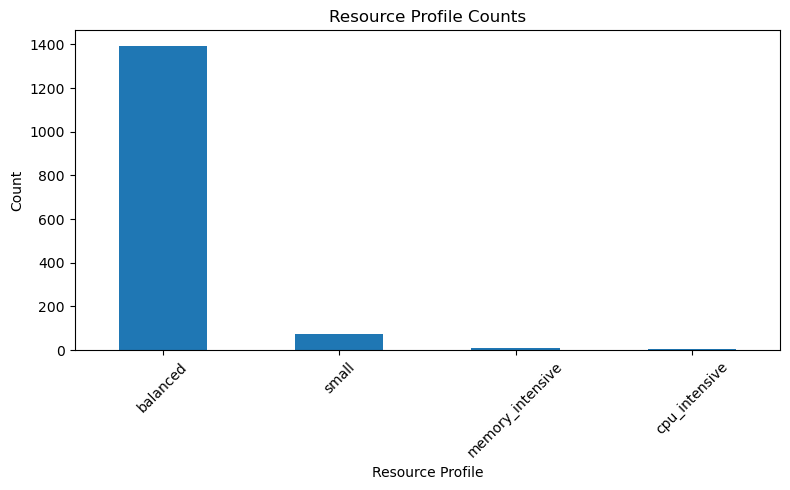

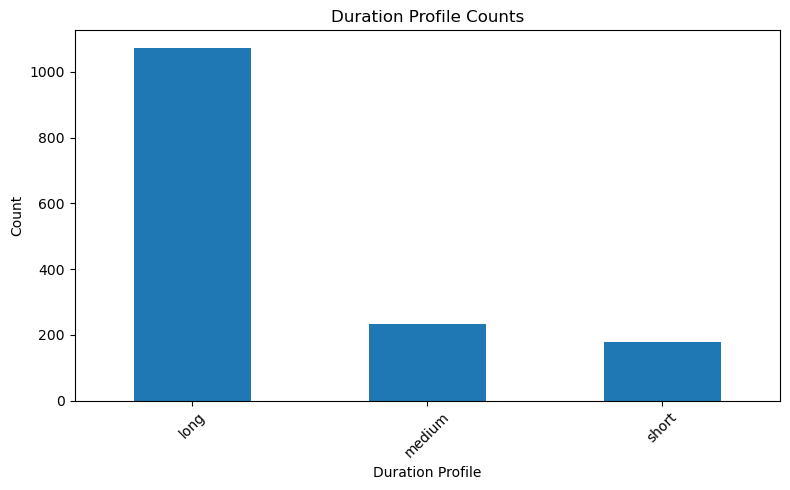

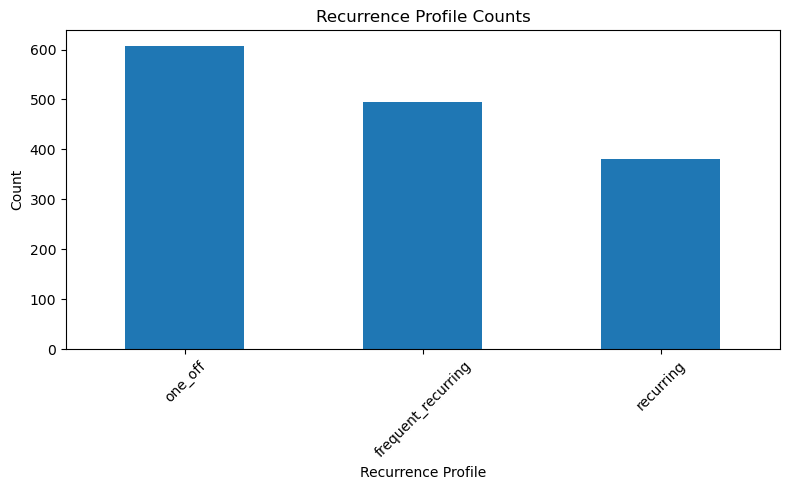

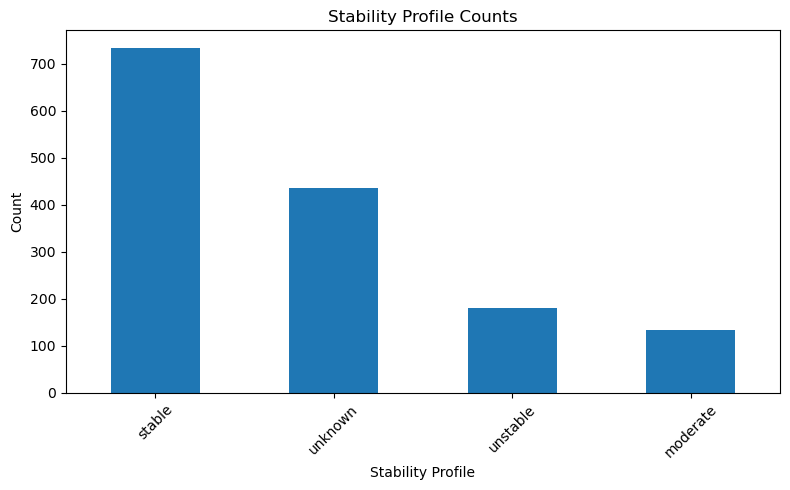

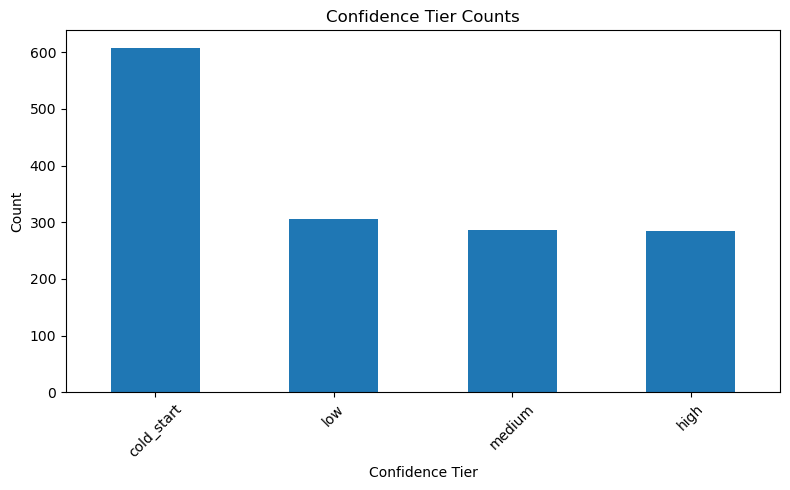

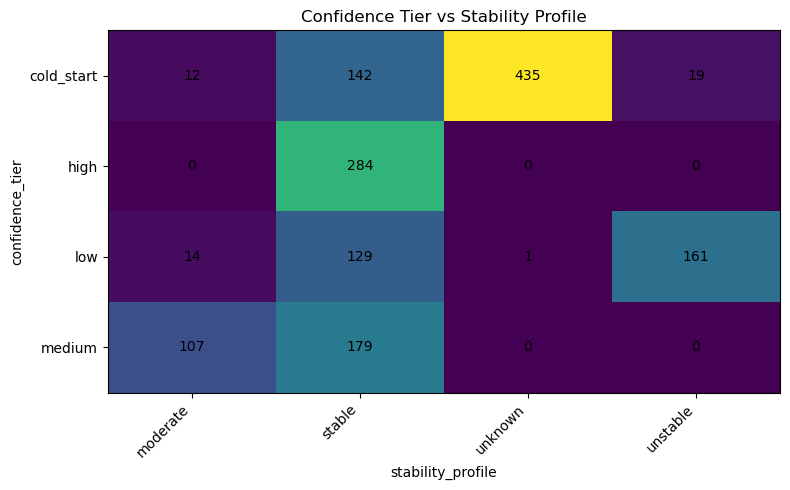

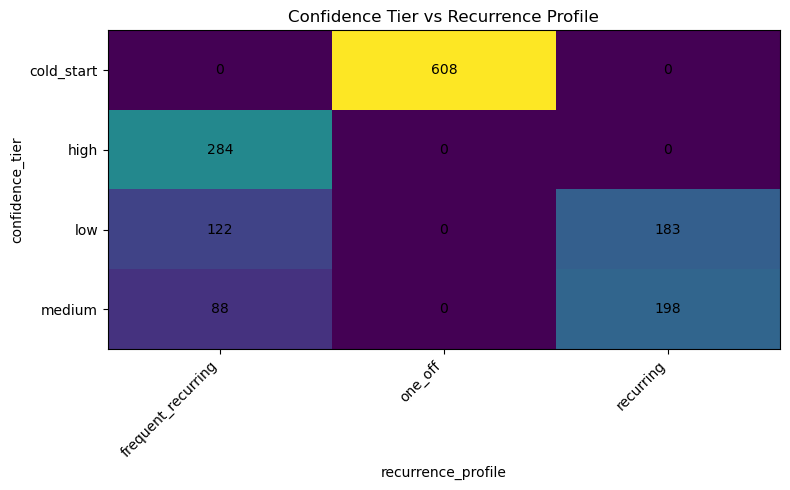

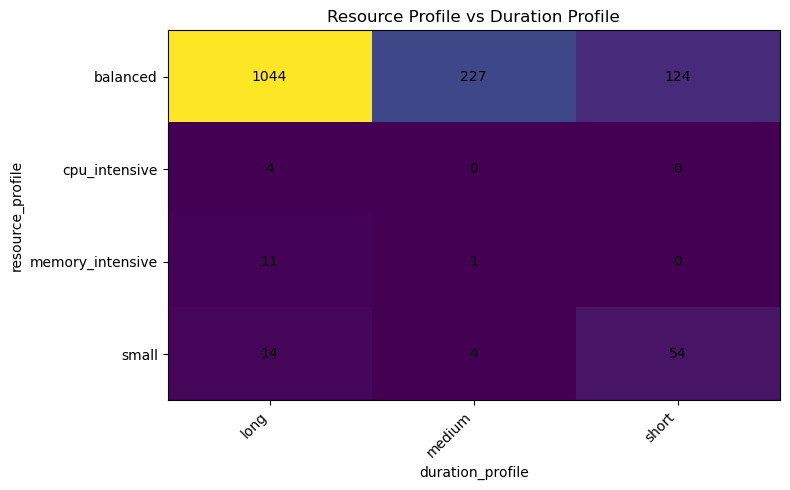

In [25]:
# Charts
# Bar Charts for Profile Counts
import matplotlib.pyplot as plt

resource_counts = job_stats["resource_profile"].value_counts()
duration_counts = job_stats["duration_profile"].value_counts()
recurrence_counts = job_stats["recurrence_profile"].value_counts()
stability_counts = job_stats["stability_profile"].value_counts()
confidence_counts = job_stats["confidence_tier"].value_counts()

plt.figure(figsize=(8, 5))
resource_counts.plot(kind="bar")
plt.title("Resource Profile Counts")
plt.xlabel("Resource Profile")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "resource_profile_counts.png")
plt.show()

plt.figure(figsize=(8, 5))
duration_counts.plot(kind="bar")
plt.title("Duration Profile Counts")
plt.xlabel("Duration Profile")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "duration_profile_counts.png")
plt.show()

plt.figure(figsize=(8, 5))
recurrence_counts.plot(kind="bar")
plt.title("Recurrence Profile Counts")
plt.xlabel("Recurrence Profile")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "recurrence_profile_counts.png")
plt.show()

plt.figure(figsize=(8, 5))
stability_counts.plot(kind="bar")
plt.title("Stability Profile Counts")
plt.xlabel("Stability Profile")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "stability_profile_counts.png")
plt.show()

plt.figure(figsize=(8, 5))
confidence_counts.plot(kind="bar")
plt.title("Confidence Tier Counts")
plt.xlabel("Confidence Tier")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "confidence_tier_counts.png")
plt.show()

# Heatmap for Cross Analysis
def plot_crosstab_heatmap(ct, title,filename):
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(ct.values, aspect="auto")

    ax.set_title(title)
    ax.set_xticks(np.arange(len(ct.columns)))
    ax.set_yticks(np.arange(len(ct.index)))
    ax.set_xticklabels(ct.columns, rotation=45, ha="right")
    ax.set_yticklabels(ct.index)

    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            ax.text(j, i, ct.iloc[i, j], ha="center", va="center")

    ax.set_xlabel(ct.columns.name if ct.columns.name else "")
    ax.set_ylabel(ct.index.name if ct.index.name else "")
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename) 
    plt.show()

ct1 = pd.crosstab(job_stats["confidence_tier"], job_stats["stability_profile"])
ct2 = pd.crosstab(job_stats["confidence_tier"], job_stats["recurrence_profile"])
ct3 = pd.crosstab(job_stats["resource_profile"], job_stats["duration_profile"])

plot_crosstab_heatmap(ct1, "Confidence Tier vs Stability Profile", "confidence_vs_stability.png")
plot_crosstab_heatmap(ct2, "Confidence Tier vs Recurrence Profile", "confidence_vs_recurrence.png")
plot_crosstab_heatmap(ct3, "Resource Profile vs Duration Profile", "resource_vs_duration.png")

In [26]:
# Save clean ingest parquet
cols_to_save = [
    "execution_id",
    "recurring_job_id",
    "recurrence_key",
    "time",
    "start_time",
    "end_time",
    "req_cpu",
    "req_mem",
    "peak_cpu",
    "peak_mem",
    "avg_cpu",
    "avg_mem",
    "slack_cpu",
    "slack_mem",
    "viol_cpu",
    "viol_mem",
    "viol_any"
]

cols_to_save = [c for c in cols_to_save if c in df_valid.columns]

df_valid[cols_to_save].to_parquet(INGEST_PARQUET_PATH, index=False)
print("Saved:", INGEST_PARQUET_PATH)
dfp = pd.read_parquet(INGEST_PARQUET_PATH)
print("Columns:", dfp.columns.tolist())
print("Shape:", dfp.shape)
display(dfp.head(5))

Saved: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/ingest_v0/subset_clean.parquet
Columns: ['execution_id', 'recurring_job_id', 'recurrence_key', 'time', 'start_time', 'end_time', 'req_cpu', 'req_mem', 'peak_cpu', 'peak_mem', 'avg_cpu', 'avg_mem', 'slack_cpu', 'slack_mem', 'viol_cpu', 'viol_mem', 'viol_any']
Shape: (98651, 17)


,execution_id,recurring_job_id,recurrence_key,time,start_time,end_time,req_cpu,req_mem,peak_cpu,peak_mem,avg_cpu,avg_mem,slack_cpu,slack_mem,viol_cpu,viol_mem,viol_any
0,83212368472_1481,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,0,2097300000000,2097600000000,0.031433,0.018677,0.017487,0.007294,0.00737,0.007271,0.013947,0.011383,0,0,0
1,83212368472_1008,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,0,2097300000000,2097600000000,0.031433,0.018677,0.017487,0.007294,0.00737,0.007271,0.013947,0.011383,0,0,0
2,83212368472_1119,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,0,2097300000000,2097600000000,0.031433,0.018677,0.017487,0.007294,0.00737,0.007271,0.013947,0.011383,0,0,0
3,83212368472_802,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,0,2097300000000,2097600000000,0.031433,0.018677,0.017487,0.007294,0.00737,0.007271,0.013947,0.011383,0,0,0
4,83212368472_2332,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,0,2097300000000,2097600000000,0.031433,0.018677,0.017487,0.007294,0.00737,0.007271,0.013947,0.011383,0,0,0


In [27]:
# Creates the ingest sanity report
ingest_summary_path = INGEST_SUMMARY_PATH
with open(ingest_summary_path, "w") as f:
    f.write("# Ingest Summary\n\n")
    f.write(f"Rows: {len(df_valid)}\n")
    f.write(f"Columns: {len(cols_to_save)}\n\n")
    f.write("## Missing Rates\n\n")
    f.write(df_valid[cols_to_save].isna().mean().sort_values(ascending=False).to_string())
    f.write("\n")

print("Saved:", ingest_summary_path)

Saved: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/reports/eval/subset/sanity/ingest_summary.md


In [28]:
# Job-level dataset
job_out = DATA_PROCESSED / "job_profiles_confidence_v0.parquet"
job_cols = [
    "recurrence_key",
    "run_count",
    "mean_peak_cpu",
    "std_peak_cpu",
    "mean_peak_mem",
    "std_peak_mem",
    "mean_duration",
    "cv_cpu",
    "cv_mem",
    "stability",
    "is_recurring",
    "confidence_tier",
    "resource_profile",
    "duration_profile",
    "recurrence_profile",
    "stability_profile",
    "p90_cpu",
    "p95_cpu",
    "p99_cpu",
    "p90_mem",
    "p95_mem",
    "p99_mem"
]
# Keep only existing columns
job_cols = [c for c in job_cols if c in job_stats.columns]
print(f"Saving {len(job_cols)} columns to job-level dataset...")
job_stats[job_cols].to_parquet(job_out, index=False)
print("Saved job-level dataset:", job_out)

# Verify
job_df = pd.read_parquet(job_out)
print("Job-level columns:")
print(job_df.columns.tolist())
display(job_df.head(5))

Saving 22 columns to job-level dataset...
Saved job-level dataset: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_profiles_confidence_v0.parquet
Job-level columns:
['recurrence_key', 'run_count', 'mean_peak_cpu', 'std_peak_cpu', 'mean_peak_mem', 'std_peak_mem', 'mean_duration', 'cv_cpu', 'cv_mem', 'stability', 'is_recurring', 'confidence_tier', 'resource_profile', 'duration_profile', 'recurrence_profile', 'stability_profile', 'p90_cpu', 'p95_cpu', 'p99_cpu', 'p90_mem', 'p95_mem', 'p99_mem']


,recurrence_key,run_count,mean_peak_cpu,std_peak_cpu,mean_peak_mem,std_peak_mem,mean_duration,cv_cpu,cv_mem,stability,is_recurring,confidence_tier,resource_profile,duration_profile,recurrence_profile,stability_profile,p90_cpu,p95_cpu,p99_cpu,p90_mem,p95_mem,p99_mem
0,++iQVWDf5/Hvnn/NXU3ttQKP/dLrqRkP3MLiZn1jKdA=||...,11,0.017487,0.0,0.007294,0.0,300000000.0,0.0,0.0,0.0,True,high,balanced,long,frequent_recurring,stable,0.017487,0.017487,0.017487,0.007294,0.007294,0.007294
1,+52peVL4nAGr4mgVjZQpkJDhArvSYmdIoludPEovCFU=||...,1,0.108276,NaN,0.008453,NaN,300000000.0,NaN,NaN,NaN,False,cold_start,balanced,long,one_off,unknown,0.108276,0.108276,0.108276,0.008453,0.008453,0.008453
2,+9EArMpTcRKY6SZ+doAw1QllovlleQnzrJD843XiIDo=||...,6,0.000370,0.0,0.000711,0.0,3000000.0,0.0,0.0,0.0,True,medium,balanced,short,recurring,stable,0.000370,0.000370,0.000370,0.000711,0.000711,0.000711
3,+9EArMpTcRKY6SZ+doAw1QllovlleQnzrJD843XiIDo=||...,1,0.000543,NaN,0.000544,NaN,300000000.0,NaN,NaN,NaN,False,cold_start,balanced,long,one_off,unknown,0.000543,0.000543,0.000543,0.000544,0.000544,0.000544
4,+9EArMpTcRKY6SZ+doAw1QllovlleQnzrJD843XiIDo=||...,1,0.000628,NaN,0.000786,NaN,300000000.0,NaN,NaN,NaN,False,cold_start,balanced,long,one_off,unknown,0.000628,0.000628,0.000628,0.000786,0.000786,0.000786


In [29]:
# Save reconstructed execution-level table
df_exec.to_parquet(JOB_EXEC_PATH, index=False)
print("Saved execution-level dataset:", JOB_EXEC_PATH)
exec_df = pd.read_parquet(JOB_EXEC_PATH)

print("Execution-level columns:")
print(exec_df.columns.tolist())

print("Shape:", exec_df.shape)

display(exec_df.head(5))

Saved execution-level dataset: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_exec_v0.parquet
Execution-level columns:
['execution_id', 'job_id', 'start_time', 'end_time', 'runtime_sec', 'duration']
Shape: (71744, 6)


,execution_id,job_id,start_time,end_time,runtime_sec,duration
0,100288420_58,100288420,976200000000,976500000000,300000000,300000000
1,10084165805_112,10084165805,958800000000,959100000000,300000000,300000000
2,10084165805_260,10084165805,958800000000,959100000000,300000000,300000000
3,10084165805_303,10084165805,958800000000,959100000000,300000000,300000000
4,10084165805_39,10084165805,958800000000,959100000000,300000000,300000000


In [30]:
runtime_summary_path = RUNTIME_SUMMARY_PATH

neg_runtime_count = int((df_exec["runtime_sec"] < 0).sum())
missing_rates = df_exec.isna().mean().sort_values(ascending=False)
runtime_stats = df_exec["runtime_sec"].describe(percentiles=[0.5, 0.95])

with open(runtime_summary_path, "w") as f:
    f.write("# Runtime Summary\n\n")
    f.write(f"Rows: {len(df_exec)}\n\n")
    f.write(f"Negative runtimes: {neg_runtime_count}\n\n")
    f.write("## Missing Rates\n\n")
    f.write(missing_rates.to_string())
    f.write("\n\n## Runtime Stats\n\n")
    f.write(runtime_stats.to_string())
    f.write("\n")

print("Saved:", runtime_summary_path)

Saved: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/reports/eval/subset/sanity/runtime_summary.md


In [31]:
assumptions_path = ASSUMPTIONS_PATH
with open(assumptions_path, "a") as f:
    f.write("\n## Ingest / Reconstruction Assumptions\n")
    f.write(f"- CPU normalization factor to cores: {CPU_TO_CORES}\n")
    f.write(f"- Memory normalization factor to GB: {MEM_TO_GB}\n")
    f.write("- execution_id = collection_id + '_' + instance_index\n")
    f.write("- execution start_time = min(start_time) per execution_id\n")
    f.write("- execution end_time = max(end_time) per execution_id\n")
    f.write("- runtime_sec = end_time - start_time\n")
    f.write("\n## Canonical Metrics Assumptions\n")
    f.write("- Canonical metrics file uses req_mem_gb and peak_mem_gb naming.\n")
    f.write("- duration in job_metrics_v0.parquet is computed as end_time - start_time in raw trace time units.\n")
    f.write("- recurrence_key is carried forward as the first observed key per execution_id.\n")
    f.write("- subset_clean.parquet may still contain req_mem and peak_mem as pre-canonical ingest names.\n")

print("Updated:", assumptions_path)

Updated: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/docs/planning/assumptions2.md


In [32]:
# Time-based split on job_metrics_v0 dataset
INPUT_PATH = JOB_METRICS_PATH
OUT_TRAIN = DATA_PROCESSED / "job_metrics_train_v0.parquet"
OUT_VAL   = DATA_PROCESSED / "job_metrics_val_v0.parquet"
OUT_TEST  = DATA_PROCESSED / "job_metrics_test_v0.parquet"

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Safety check
assert abs((TRAIN_FRAC + VAL_FRAC + TEST_FRAC) - 1.0) < 1e-9, "Split fractions must sum to 1.0"

# Load
df = pd.read_parquet(INPUT_PATH)
print(f"Loaded rows: {len(df):,}")
print("Columns:", list(df.columns))
print("Input path:", INPUT_PATH)

# Parse and validate time column
if "start_time" not in df.columns:
    raise ValueError("Expected 'start_time' column not found.")

df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
if "end_time" in df.columns:
    df["end_time"] = pd.to_datetime(df["end_time"], errors="coerce")
else:
    df["end_time"] = pd.NaT

bad_start = df["start_time"].isna().sum()
if bad_start > 0:
    print(f"Dropping {bad_start:,} rows with invalid start_time")
    df = df.dropna(subset=["start_time"]).copy()

# Sort by time
sort_cols = ["start_time"]
if "execution_id" in df.columns:
    sort_cols.append("execution_id")
df = df.sort_values(sort_cols, kind="mergesort").reset_index(drop=True)

# Split by time order
n = len(df)
train_end = int(n * TRAIN_FRAC)
val_end = int(n * (TRAIN_FRAC + VAL_FRAC))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

# Save
train_df.to_parquet(OUT_TRAIN, index=False)
val_df.to_parquet(OUT_VAL, index=False)
test_df.to_parquet(OUT_TEST, index=False)

# Validation checks
print("\nSaved files:")
print(OUT_TRAIN)
print(OUT_VAL)
print(OUT_TEST)

print("\nRow counts:")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df):,}")

assert len(train_df) + len(val_df) + len(test_df) == len(df), "Row counts do not add up."

def time_range(name, part):
    if len(part) == 0:
        print(f"{name}: EMPTY")
        return
    print(
        f"{name}: "
        f"{part['start_time'].min()}  -->  {part['start_time'].max()}"
    )

print("\nTime ranges:")
time_range("Train", train_df)
time_range("Val  ", val_df)
time_range("Test ", test_df)

if len(train_df) > 0 and len(val_df) > 0:
    assert train_df["start_time"].max() <= val_df["start_time"].min(), \
        "Train/Val temporal ordering is broken."

if len(val_df) > 0 and len(test_df) > 0:
    assert val_df["start_time"].max() <= test_df["start_time"].min(), \
        "Val/Test temporal ordering is broken."

print("\nSplit completed successfully.")

Loaded rows: 71,744
Columns: ['execution_id', 'job_id', 'start_time', 'end_time', 'req_cpu', 'req_mem_gb', 'peak_cpu', 'peak_mem_gb', 'recurrence_key', 'timestamp', 'duration', 'slack_req_cpu', 'slack_req_mem_gb']
Input path: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_v0.parquet

Saved files:
/Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_train_v0.parquet
/Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_val_v0.parquet
/Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_test_v0.parquet

Row counts:
Train: 50,220
Val  : 10,762
Test : 10,762
Total: 71,744

Time ranges:
Train: 1970-01-01 00:00:00.600000  -->  1970-01-01 00:30:08.700000
Val  : 1970-01-01 00:30:08.700000  -->  1970-01-01 00:37:29.100000
Test : 1970-01-01 00:37:29.100000  -->  1970-01-01 00:44:38.400000

Split completed successfully.


In [33]:
all_exec = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)
# Check whether earlier-starting executions were actually complete before later executions began.
check = all_exec.copy()

check["start_time"] = pd.to_numeric(
    check["start_time"], errors="coerce"
)

check["end_time"] = pd.to_numeric(
    check["end_time"], errors="coerce"
)

check = check.sort_values(
    ["recurrence_key", "start_time", "end_time"],
    kind="mergesort"
)

check["prev_end_time"] = (
    check.groupby("recurrence_key")["end_time"]
         .shift(1)
)

overlap = (
    check["prev_end_time"].notna()
    & (check["prev_end_time"] > check["start_time"])
)

same_start = (
    check.groupby("recurrence_key")["start_time"]
         .transform(lambda s: s.duplicated(keep=False))
)

print("Overlapping executions:", int(overlap.sum()))
print("Same-start executions :", int(same_start.sum()))

Overlapping executions: 68693
Same-start executions : 70862


In [34]:
import pandas as pd
import numpy as np

# Step 2: Build point-in-time historical profiles.
# IMPORTANT:
# For execution E_t, only executions from the same recurrence group whose
# end_time <= E_t.start_time are available as historical observations.

TRAIN_PATH = DATA_PROCESSED / "job_metrics_train_v0.parquet"
VAL_PATH   = DATA_PROCESSED / "job_metrics_val_v0.parquet"
TEST_PATH  = DATA_PROCESSED / "job_metrics_test_v0.parquet"

train_df = pd.read_parquet(TRAIN_PATH).copy()
val_df   = pd.read_parquet(VAL_PATH).copy()
test_df  = pd.read_parquet(TEST_PATH).copy()

train_df["_split"] = "train"
val_df["_split"] = "val"
test_df["_split"] = "test"

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print(f"Loaded total rows: {len(df):,}")
print("Columns:", list(df.columns))


# ---------------------------------------------------------
# Basic cleanup
# ---------------------------------------------------------

required_cols = [
    "recurrence_key",
    "start_time",
    "end_time",
    "peak_cpu",
    "peak_mem_gb",
    "duration",
]

if "execution_id" in df.columns:
    required_cols.append("execution_id")

missing = [
    c for c in required_cols
    if c not in df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

work = df[
    required_cols + ["_split"]
].copy()

before = len(work)

work = work.dropna(
    subset=["recurrence_key", "start_time", "end_time"]
)

print(
    "Dropped rows with null recurrence_key/start_time/end_time:",
    f"{before - len(work):,}"
)


# Ensure time columns use the same representation
work["start_time"] = pd.to_datetime(
    work["start_time"],
    errors="coerce"
)

work["end_time"] = pd.to_datetime(
    work["end_time"],
    errors="coerce"
)


# Ensure resource values are numeric
for col in [
    "peak_cpu",
    "peak_mem_gb",
    "duration",
]:
    work[col] = pd.to_numeric(
        work[col],
        errors="coerce"
    )


before = len(work)

work = work.dropna(
    subset=[
        "peak_cpu",
        "peak_mem_gb",
        "duration",
    ],
    how="all"
)

print(
    "Dropped rows with all key metrics missing:",
    f"{before - len(work):,}"
)


# ---------------------------------------------------------
# Preserve a unique row identifier.
# This lets us restore the original execution rows after
# constructing history in end-time order.
# ---------------------------------------------------------

work["_row_id"] = np.arange(len(work))


# ---------------------------------------------------------
# Historical feature construction
#
# For each recurrence group:
#
# current execution at start_time T
#       ↓
# eligible history = executions with end_time <= T
#
# This prevents:
# - overlapping executions from seeing unfinished outcomes
# - same-start executions from seeing each other's outcomes
# ---------------------------------------------------------

history_rows = []

for recurrence_key, group in work.groupby(
    "recurrence_key",
    sort=False
):

    group = group.copy()

    # Executions for which we need a recommendation/profile
    targets = group.sort_values(
        ["start_time", "_row_id"],
        kind="mergesort"
    )

    # Executions become available as history only when they END
    completed = group.sort_values(
        ["end_time", "_row_id"],
        kind="mergesort"
    )

    completed_records = completed.to_dict("records")

    history_cpu = []
    history_mem = []
    history_duration = []

    completed_idx = 0

    for _, row in targets.iterrows():

        current_start = row["start_time"]

        # Add every execution whose outcome was available
        # at or before the current execution's start.
        while (
            completed_idx < len(completed_records)
            and completed_records[completed_idx]["end_time"]
                <= current_start
        ):
            previous = completed_records[completed_idx]

            if pd.notna(previous["peak_cpu"]):
                history_cpu.append(
                    float(previous["peak_cpu"])
                )

            if pd.notna(previous["peak_mem_gb"]):
                history_mem.append(
                    float(previous["peak_mem_gb"])
                )

            if pd.notna(previous["duration"]):
                history_duration.append(
                    float(previous["duration"])
                )

            completed_idx += 1

        run_count = completed_idx

        # CPU historical statistics
        if history_cpu:
            cpu = np.asarray(
                history_cpu,
                dtype=float
            )

            mean_peak_cpu = float(np.mean(cpu))

            std_peak_cpu = (
                float(np.std(cpu, ddof=1))
                if len(cpu) >= 2
                else np.nan
            )

            p90_cpu = float(
                np.quantile(cpu, 0.90)
            )

            p95_cpu = float(
                np.quantile(cpu, 0.95)
            )

            p99_cpu = float(
                np.quantile(cpu, 0.99)
            )

        else:
            mean_peak_cpu = np.nan
            std_peak_cpu = np.nan
            p90_cpu = np.nan
            p95_cpu = np.nan
            p99_cpu = np.nan


        # Memory historical statistics
        if history_mem:
            mem = np.asarray(
                history_mem,
                dtype=float
            )

            mean_peak_mem = float(np.mean(mem))

            std_peak_mem = (
                float(np.std(mem, ddof=1))
                if len(mem) >= 2
                else np.nan
            )

            p90_mem = float(
                np.quantile(mem, 0.90)
            )

            p95_mem = float(
                np.quantile(mem, 0.95)
            )

            p99_mem = float(
                np.quantile(mem, 0.99)
            )

        else:
            mean_peak_mem = np.nan
            std_peak_mem = np.nan
            p90_mem = np.nan
            p95_mem = np.nan
            p99_mem = np.nan


        # Historical duration
        mean_duration = (
            float(np.mean(history_duration))
            if history_duration
            else np.nan
        )


        # Historical CV
        cv_cpu = (
            std_peak_cpu / mean_peak_cpu
            if (
                pd.notna(std_peak_cpu)
                and pd.notna(mean_peak_cpu)
                and abs(mean_peak_cpu) > 1e-12
            )
            else np.nan
        )

        cv_mem = (
            std_peak_mem / mean_peak_mem
            if (
                pd.notna(std_peak_mem)
                and pd.notna(mean_peak_mem)
                and abs(mean_peak_mem) > 1e-12
            )
            else np.nan
        )


        # Stability = variability of the less-stable resource
        available_cv = [
            x for x in [cv_cpu, cv_mem]
            if pd.notna(x)
        ]

        stability = (
            max(available_cv)
            if available_cv
            else np.nan
        )


        history_rows.append({
            "_row_id": row["_row_id"],
            "run_count": run_count,

            "mean_peak_cpu": mean_peak_cpu,
            "std_peak_cpu": std_peak_cpu,

            "mean_peak_mem": mean_peak_mem,
            "std_peak_mem": std_peak_mem,

            "mean_duration": mean_duration,

            "cv_cpu": cv_cpu,
            "cv_mem": cv_mem,
            "stability": stability,

            "p90_cpu": p90_cpu,
            "p95_cpu": p95_cpu,
            "p99_cpu": p99_cpu,

            "p90_mem": p90_mem,
            "p95_mem": p95_mem,
            "p99_mem": p99_mem,
        })


# ---------------------------------------------------------
# Attach historical statistics back to each execution
# ---------------------------------------------------------

history_df = pd.DataFrame(history_rows)

work = work.merge(
    history_df,
    on="_row_id",
    how="left",
    validate="one_to_one"
)


# ---------------------------------------------------------
# Derived historical features
# ---------------------------------------------------------

work["is_recurring"] = (
    work["run_count"] >= 1
)


# Confidence = history depth + historical stability
def assign_confidence_tier(run_count, stability):

    rc = (
        0
        if pd.isna(run_count)
        else float(run_count)
    )

    s = (
        float("inf")
        if pd.isna(stability)
        else float(stability)
    )

    if rc >= 30 and s < 0.50:
        return "high"

    if rc >= 30:
        return "medium"

    if rc >= 10 and s < 0.75:
        return "medium"

    return "low"


work["confidence_tier"] = [
    assign_confidence_tier(rc, stability)
    for rc, stability in zip(
        work["run_count"],
        work["stability"]
    )
]


# ---------------------------------------------------------
# Descriptive labels
# ---------------------------------------------------------

def resource_profile(row):

    cpu = row["mean_peak_cpu"]
    mem = row["mean_peak_mem"]

    if pd.isna(cpu) or pd.isna(mem):
        return "unknown"

    if cpu >= mem:
        return "cpu_heavy"

    return "mem_heavy"


def duration_profile(d):

    if pd.isna(d):
        return "unknown"

    if d < 60:
        return "short"

    if d < 300:
        return "medium"

    return "long"


def recurrence_profile(rc):

    if pd.isna(rc):
        return "unknown"

    if rc == 0:
        return "one_off"

    if rc < 5:
        return "low_repeat"

    if rc < 20:
        return "repeat"

    return "high_repeat"


def stability_profile(s):

    if pd.isna(s):
        return "unknown"

    if s < 0.10:
        return "stable"

    if s < 0.30:
        return "moderate"

    return "volatile"


work["resource_profile"] = (
    work.apply(
        resource_profile,
        axis=1
    )
)

work["duration_profile"] = (
    work["mean_duration"]
    .apply(duration_profile)
)

work["recurrence_profile"] = (
    work["run_count"]
    .apply(recurrence_profile)
)

work["stability_profile"] = (
    work["stability"]
    .apply(stability_profile)
)


# ---------------------------------------------------------
# Save point-in-time historical profiles by split
# ---------------------------------------------------------

OUT_TRAIN_PROFILES = (
    DATA_PROCESSED
    / "job_profiles_train_history_v1.parquet"
)

OUT_VAL_PROFILES = (
    DATA_PROCESSED
    / "job_profiles_val_history_v1.parquet"
)

OUT_TEST_PROFILES = (
    DATA_PROCESSED
    / "job_profiles_test_history_v1.parquet"
)


profile_cols = [
    "recurrence_key",
    "start_time",
]

if "execution_id" in work.columns:
    profile_cols.append(
        "execution_id"
    )

profile_cols += [
    "run_count",

    "mean_peak_cpu",
    "std_peak_cpu",

    "mean_peak_mem",
    "std_peak_mem",

    "mean_duration",

    "cv_cpu",
    "cv_mem",
    "stability",

    "is_recurring",
    "confidence_tier",

    "resource_profile",
    "duration_profile",
    "recurrence_profile",
    "stability_profile",

    "p90_cpu",
    "p95_cpu",
    "p99_cpu",

    "p90_mem",
    "p95_mem",
    "p99_mem",
]


train_profiles = (
    work.loc[
        work["_split"] == "train",
        profile_cols
    ]
    .copy()
)

val_profiles = (
    work.loc[
        work["_split"] == "val",
        profile_cols
    ]
    .copy()
)

test_profiles = (
    work.loc[
        work["_split"] == "test",
        profile_cols
    ]
    .copy()
)


train_profiles.to_parquet(
    OUT_TRAIN_PROFILES,
    index=False
)

val_profiles.to_parquet(
    OUT_VAL_PROFILES,
    index=False
)

test_profiles.to_parquet(
    OUT_TEST_PROFILES,
    index=False
)


print(
    "\nSaved point-in-time historical profiles:"
)

print(
    "Train:",
    OUT_TRAIN_PROFILES
)

print(
    "Val  :",
    OUT_VAL_PROFILES
)

print(
    "Test :",
    OUT_TEST_PROFILES
)


print("\nProfile row counts:")

print(
    f"Train: {len(train_profiles):,}"
)

print(
    f"Val  : {len(val_profiles):,}"
)

print(
    f"Test : {len(test_profiles):,}"
)


print("\nAvailable-history count summary:")

print(
    work["run_count"].describe()
)

Loaded total rows: 71,744
Columns: ['execution_id', 'job_id', 'start_time', 'end_time', 'req_cpu', 'req_mem_gb', 'peak_cpu', 'peak_mem_gb', 'recurrence_key', 'timestamp', 'duration', 'slack_req_cpu', 'slack_req_mem_gb', '_split']
Dropped rows with null recurrence_key/start_time/end_time: 0
Dropped rows with all key metrics missing: 0

Saved point-in-time historical profiles:
Train: /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_profiles_train_history_v1.parquet
Val  : /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_profiles_val_history_v1.parquet
Test : /Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_profiles_test_history_v1.parquet

Profile row counts:
Train: 50,220
Val  : 10,762
Test : 10,762

Available-history count summary:
count    71744.000000
mean       722.332599
std       1671.774193
min          0.000000
25%          0.000000
50%         34.000000
75%        4

In [35]:
import pandas as pd
import numpy as np

# STEP 3: Attach point-in-time historical profiles and generate baselines
VAL_PATH = DATA_PROCESSED / "job_metrics_val_v0.parquet"
TEST_PATH = DATA_PROCESSED / "job_metrics_test_v0.parquet"
VAL_PROFILE_PATH = DATA_PROCESSED / "job_profiles_val_history_v1.parquet"
TEST_PROFILE_PATH = DATA_PROCESSED / "job_profiles_test_history_v1.parquet"

OUT_VAL_BASELINES = DATA_PROCESSED / "job_metrics_val_with_baselines_v0.parquet"
OUT_TEST_BASELINES = DATA_PROCESSED / "job_metrics_test_with_baselines_v0.parquet"

# Load
val_df = pd.read_parquet(VAL_PATH)
test_df = pd.read_parquet(TEST_PATH)

val_profiles = pd.read_parquet(VAL_PROFILE_PATH)
test_profiles = pd.read_parquet(TEST_PROFILE_PATH)

print(f"Loaded val rows      : {len(val_df):,}")
print(f"Loaded test rows     : {len(test_df):,}")
print(f"Loaded val profiles  : {len(val_profiles):,}")
print(f"Loaded test profiles : {len(test_profiles):,}")

# Keep only needed profile columns for join
# Include execution-level identifiers because profiles are now point-in-time

profile_cols = [
    "recurrence_key",
    "start_time",
]

if (
    "execution_id" in val_profiles.columns
    and "execution_id" in test_profiles.columns
):
    profile_cols.append("execution_id")

profile_cols += [
    "run_count",
    "mean_peak_cpu",
    "std_peak_cpu",
    "mean_peak_mem",
    "std_peak_mem",
    "mean_duration",
    "cv_cpu",
    "cv_mem",
    "stability",
    "is_recurring",
    "confidence_tier",
    "resource_profile",
    "duration_profile",
    "recurrence_profile",
    "stability_profile",
    "p90_cpu",
    "p95_cpu",
    "p99_cpu",
    "p90_mem",
    "p95_mem",
    "p99_mem",
]

val_profiles = val_profiles[profile_cols].copy()
test_profiles = test_profiles[profile_cols].copy()

# Rename profile columns so historical features are clearly identified
rename_map = {
    "run_count": "hist_run_count",
    "mean_peak_cpu": "hist_mean_peak_cpu",
    "std_peak_cpu": "hist_std_peak_cpu",
    "mean_peak_mem": "hist_mean_peak_mem",
    "std_peak_mem": "hist_std_peak_mem",
    "mean_duration": "hist_mean_duration",
    "cv_cpu": "hist_cv_cpu",
    "cv_mem": "hist_cv_mem",
    "stability": "hist_stability",
    "is_recurring": "hist_is_recurring",
    "confidence_tier": "hist_confidence_tier",
    "resource_profile": "hist_resource_profile",
    "duration_profile": "hist_duration_profile",
    "recurrence_profile": "hist_recurrence_profile",
    "stability_profile": "hist_stability_profile",
    "p90_cpu": "hist_p90_cpu",
    "p95_cpu": "hist_p95_cpu",
    "p99_cpu": "hist_p99_cpu",
    "p90_mem": "hist_p90_mem",
    "p95_mem": "hist_p95_mem",
    "p99_mem": "hist_p99_mem",
}
val_profiles = val_profiles.rename(columns=rename_map)
test_profiles = test_profiles.rename(columns=rename_map)

# Attach the point-in-time historical profile for the same execution
val_df["start_time"] = pd.to_datetime(val_df["start_time"], errors="coerce")
test_df["start_time"] = pd.to_datetime(test_df["start_time"], errors="coerce")

val_profiles["start_time"] = pd.to_datetime(
    val_profiles["start_time"], errors="coerce"
)
test_profiles["start_time"] = pd.to_datetime(
    test_profiles["start_time"], errors="coerce"
)

join_cols = ["recurrence_key", "start_time"]

if (
    "execution_id" in val_df.columns
    and "execution_id" in test_df.columns
    and "execution_id" in val_profiles.columns
    and "execution_id" in test_profiles.columns
):
    join_cols.append("execution_id")

val = val_df.merge(
    val_profiles,
    on=join_cols,
    how="left",
    validate="one_to_one"
)

test = test_df.merge(
    test_profiles,
    on=join_cols,
    how="left",
    validate="one_to_one"
)

# Make sure the merge did not duplicate executions
assert len(val) == len(val_df)
assert len(test) == len(test_df)

# Cold-start visibility: no prior execution history
val_cold = (val["hist_run_count"].fillna(0) == 0).sum()
test_cold = (test["hist_run_count"].fillna(0) == 0).sum()

print("\nRows with no prior recurrence history:")
print(f"Validation: {val_cold:,}")
print(f"Test      : {test_cold:,}")


# Generate baseline recommendation columns
# Strategy:
# - requested baseline: original requested resources
# - p90 / p95 / p99 baselines from prior execution history
# - fallback when no prior history is available: use request
def add_baselines(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Requested baseline
    out["base_req_cpu"] = out["req_cpu"]
    out["base_req_mem"] = out["req_mem_gb"]
    # Mean history baseline
    out["base_mean_cpu"] = out["hist_mean_peak_cpu"].fillna(out["req_cpu"])
    out["base_mean_mem"] = out["hist_mean_peak_mem"].fillna(out["req_mem_gb"])

    # Quantile baselines
    out["base_p90_cpu"] = out["hist_p90_cpu"].fillna(out["req_cpu"])
    out["base_p90_mem"] = out["hist_p90_mem"].fillna(out["req_mem_gb"])

    out["base_p95_cpu"] = out["hist_p95_cpu"].fillna(out["req_cpu"])
    out["base_p95_mem"] = out["hist_p95_mem"].fillna(out["req_mem_gb"])

    out["base_p99_cpu"] = out["hist_p99_cpu"].fillna(out["req_cpu"])
    out["base_p99_mem"] = out["hist_p99_mem"].fillna(out["req_mem_gb"])

    # Baseline source tags
    out["base_mean_source"] = np.where(out["hist_mean_peak_cpu"].notna(), "history", "request_fallback")
    out["base_p90_source"] = np.where(out["hist_p90_cpu"].notna(), "history", "request_fallback")
    out["base_p95_source"] = np.where(out["hist_p95_cpu"].notna(), "history", "request_fallback")
    out["base_p99_source"] = np.where(out["hist_p99_cpu"].notna(), "history", "request_fallback")

    return out

val = add_baselines(val)
test = add_baselines(test)

# Save
val.to_parquet(OUT_VAL_BASELINES, index=False)
test.to_parquet(OUT_TEST_BASELINES, index=False)

print("\nSaved files:")
print(OUT_VAL_BASELINES)
print(OUT_TEST_BASELINES)


print("\nValidation baseline columns created:")
print([
    "base_req_cpu", "base_req_mem",
    "base_mean_cpu", "base_mean_mem",
    "base_p90_cpu", "base_p90_mem",
    "base_p95_cpu", "base_p95_mem",
    "base_p99_cpu", "base_p99_mem"
])

print("\nSample baseline coverage:")
print("Validation history-backed P95 CPU rows:", int((val["base_p95_source"] == "history").sum()))
print("Validation fallback P95 CPU rows     :", int((val["base_p95_source"] == "request_fallback").sum()))
print("Test history-backed P95 CPU rows      :", int((test["base_p95_source"] == "history").sum()))
print("Test fallback P95 CPU rows             :", int((test["base_p95_source"] == "request_fallback").sum()))

print("\nStep 3 completed: profiles attached and baselines generated.")

Loaded val rows      : 10,762
Loaded test rows     : 10,762
Loaded val profiles  : 10,762
Loaded test profiles : 10,762

Rows with no prior recurrence history:
Validation: 2,128
Test      : 3,050

Saved files:
/Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_val_with_baselines_v0.parquet
/Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_test_with_baselines_v0.parquet

Validation baseline columns created:
['base_req_cpu', 'base_req_mem', 'base_mean_cpu', 'base_mean_mem', 'base_p90_cpu', 'base_p90_mem', 'base_p95_cpu', 'base_p95_mem', 'base_p99_cpu', 'base_p99_mem']

Sample baseline coverage:
Validation history-backed P95 CPU rows: 8634
Validation fallback P95 CPU rows     : 2128
Test history-backed P95 CPU rows      : 7712
Test fallback P95 CPU rows             : 3050

Step 3 completed: profiles attached and baselines generated.


In [36]:
from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------------------
# STEP 4A: Post-execution evaluation of baselines on validation only
# Test outcomes are reserved for final evaluation in Notebook 6.
# ------------------------------------------------------------------------

# Resolve project root
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

VAL_BASE_PATH = DATA_PROCESSED / "job_metrics_val_with_baselines_v0.parquet"

OUT_VAL_EVAL = DATA_PROCESSED / "job_metrics_val_evaluated_v2.parquet"

# Load validation only
val = pd.read_parquet(VAL_BASE_PATH)

print(f"Loaded validation rows: {len(val):,}")

baseline_names = ["req", "mean", "p90", "p95", "p99"]

# Check baseline columns
for b in baseline_names:
    for col in [f"base_{b}_cpu", f"base_{b}_mem"]:
        if col not in val.columns:
            raise ValueError(f"Missing baseline column: {col}")

# Check actual outcome columns needed for validation evaluation
required_actual_cols = ["peak_cpu", "peak_mem_gb", "req_cpu", "req_mem_gb"]

for col in required_actual_cols:
    if col not in val.columns:
        raise ValueError(f"Missing required actual column: {col}")

MIN_RESOURCE = 1e-3


def evaluate_baselines(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for b in baseline_names:
        cpu_col = f"base_{b}_cpu"
        mem_col = f"base_{b}_mem"

        # Violation
        out[f"viol_cpu_{b}"] = out["peak_cpu"] > out[cpu_col]
        out[f"viol_mem_{b}"] = out["peak_mem_gb"] > out[mem_col]
        out[f"viol_any_{b}"] = (
            out[f"viol_cpu_{b}"] | out[f"viol_mem_{b}"]
        )

        # Slack
        out[f"slack_cpu_{b}"] = out[cpu_col] - out["peak_cpu"]
        out[f"slack_mem_{b}"] = out[mem_col] - out["peak_mem_gb"]

        # Over-provisioning / waste
        out[f"waste_cpu_{b}"] = np.maximum(
            out[f"slack_cpu_{b}"], 0
        )
        out[f"waste_mem_{b}"] = np.maximum(
            out[f"slack_mem_{b}"], 0
        )

        # Under-provisioning / shortfall
        out[f"short_cpu_{b}"] = np.maximum(
            out["peak_cpu"] - out[cpu_col], 0
        )
        out[f"short_mem_{b}"] = np.maximum(
            out["peak_mem_gb"] - out[mem_col], 0
        )

        # Utilization
        out[f"cpu_util_{b}"] = np.where(
            out[cpu_col] > MIN_RESOURCE,
            out["peak_cpu"] / out[cpu_col],
            np.nan
        )

        out[f"mem_util_{b}"] = np.where(
            out[mem_col] > MIN_RESOURCE,
            out["peak_mem_gb"] / out[mem_col],
            np.nan
        )

    return out


# Evaluate validation only
val_eval = evaluate_baselines(val)

# Save validation evaluation artifact
val_eval.to_parquet(OUT_VAL_EVAL, index=False)

print("\nSaved validation evaluated artifact:")
print(OUT_VAL_EVAL)

print("\nStep 4A completed.")

Loaded validation rows: 10,762

Saved validation evaluated artifact:
/Users/sonalilonkar/Desktop/295AB/295A/TraceAdvisor/masters-project/data/processed/job_metrics_val_evaluated_v2.parquet

Step 4A completed.


In [38]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# STEP 4B: Validation results, summary table, and key plots
# Test evaluation is reserved for the final locked evaluation.
# ------------------------------------------------------------

# Resolve project root
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_SUBSET = PROJECT_ROOT / "reports" / "eval" / "subset"
REPORTS_TABLES = REPORTS_SUBSET / "tables"
REPORTS_FIGURES = REPORTS_SUBSET / "figures"
REPORTS_SANITY = REPORTS_SUBSET / "sanity"

REPORTS_TABLES.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)
REPORTS_SANITY.mkdir(parents=True, exist_ok=True)

VAL_EVAL_PATH = DATA_PROCESSED / "job_metrics_val_evaluated_v2.parquet"

OUT_VAL_SUMMARY = (
    REPORTS_TABLES / "google_cluster_subset_validation_summary.csv"
)

OUT_COMPACT_MD = (
    REPORTS_SANITY / "google_cluster_subset_baseline_comparison.md"
)

# Load validation evaluation only
val_eval = pd.read_parquet(VAL_EVAL_PATH)

baseline_names = ["req", "mean", "p90", "p95", "p99"]
baseline_order = ["req", "mean", "p90", "p95", "p99"]


def make_summary(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    rows = []

    for b in baseline_names:
        rows.append({
            "split": split_name,
            "baseline": b,
            "cpu_violation_rate": df[f"viol_cpu_{b}"].mean(),
            "mem_violation_rate": df[f"viol_mem_{b}"].mean(),
            "any_violation_rate": df[f"viol_any_{b}"].mean(),
            "avg_cpu_slack": df[f"slack_cpu_{b}"].mean(),
            "avg_mem_slack": df[f"slack_mem_{b}"].mean(),
            "avg_cpu_waste": df[f"waste_cpu_{b}"].mean(),
            "avg_mem_waste": df[f"waste_mem_{b}"].mean(),
            "avg_cpu_shortfall": df[f"short_cpu_{b}"].mean(),
            "avg_mem_shortfall": df[f"short_mem_{b}"].mean(),
            "avg_cpu_utilization": df[f"cpu_util_{b}"].mean(),
            "avg_mem_utilization": df[f"mem_util_{b}"].mean(),
            "median_cpu_utilization": df[f"cpu_util_{b}"].median(),
            "median_mem_utilization": df[f"mem_util_{b}"].median(),
            "cpu_util_valid_rows": df[f"cpu_util_{b}"].notna().sum(),
            "mem_util_valid_rows": df[f"mem_util_{b}"].notna().sum(),
        })

    return pd.DataFrame(rows)


# Validation summary only
val_summary = make_summary(val_eval, "validation")

compact_cols = [
    "split",
    "baseline",
    "cpu_violation_rate",
    "mem_violation_rate",
    "any_violation_rate",
    "avg_cpu_waste",
    "avg_mem_waste",
    "avg_cpu_utilization",
    "avg_mem_utilization",
    "cpu_util_valid_rows",
    "mem_util_valid_rows",
]

compact = (
    val_summary[compact_cols]
    .sort_values("baseline")
    .reset_index(drop=True)
)

# Save validation summary
val_summary.to_csv(OUT_VAL_SUMMARY, index=False)

# Save validation comparison as markdown
with open(OUT_COMPACT_MD, "w", encoding="utf-8") as f:
    f.write("# Google Cluster Subset Baseline Comparison\n\n")
    f.write(
        "This table reports validation baseline metrics. "
        "Validation results may be used for baseline and policy selection. "
        "The test split is reserved for final held-out evaluation after "
        "model and policy choices are locked.\n\n"
    )
    f.write(compact.to_markdown(index=False))

# Display
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

print("\nValidation summary:")
print(val_summary)

print("\nCompact validation comparison:")
print(compact)


# ------------------------------------------------------------
# Plot helper — validation only
# ------------------------------------------------------------

def plot_metric(
    summary: pd.DataFrame,
    metric: str,
    ylabel: str,
    out_path: Path
):
    part = (
        summary
        .set_index("baseline")
        .reindex(baseline_order)[metric]
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))

    x = np.arange(len(baseline_order))

    ax.bar(x, part.values)

    ax.set_xticks(x)
    ax.set_xticklabels(baseline_order)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Validation: {ylabel}")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)


# Plot 1: Validation Any Violation Rate
OUT_ANY_VIOLATION_PNG = (
    REPORTS_FIGURES /
    "google_cluster_subset_validation_any_violation_rate.png"
)

plot_metric(
    val_summary,
    metric="any_violation_rate",
    ylabel="Any Violation Rate",
    out_path=OUT_ANY_VIOLATION_PNG
)


# Plot 2: Validation Average CPU Waste
OUT_CPU_WASTE_PNG = (
    REPORTS_FIGURES /
    "google_cluster_subset_validation_avg_cpu_waste.png"
)

plot_metric(
    val_summary,
    metric="avg_cpu_waste",
    ylabel="Average CPU Waste",
    out_path=OUT_CPU_WASTE_PNG
)


# Plot 3: Validation reliability vs efficiency tradeoff
OUT_TRADEOFF_PNG = (
    REPORTS_FIGURES /
    "google_cluster_subset_validation_reliability_efficiency_tradeoff.png"
)

fig, ax = plt.subplots(figsize=(6.5, 5))

val_plot = (
    val_summary
    .set_index("baseline")
    .reindex(baseline_order)
    .reset_index()
)

ax.scatter(
    val_plot["any_violation_rate"],
    val_plot["avg_cpu_waste"]
)

for _, row in val_plot.iterrows():
    ax.annotate(
        row["baseline"],
        (row["any_violation_rate"], row["avg_cpu_waste"])
    )

ax.set_xlabel("Any Violation Rate")
ax.set_ylabel("Average CPU Waste")
ax.set_title("Validation: Reliability vs Efficiency Tradeoff")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    OUT_TRADEOFF_PNG,
    dpi=200,
    bbox_inches="tight"
)
plt.close(fig)


print("\nSaved validation report table:")
print(OUT_VAL_SUMMARY)

print("\nSaved validation comparison:")
print(OUT_COMPACT_MD)

print("\nSaved validation figures:")
print(OUT_ANY_VIOLATION_PNG)
print(OUT_CPU_WASTE_PNG)
print(OUT_TRADEOFF_PNG)


Validation summary:
        split baseline  cpu_violation_rate  mem_violation_rate  \
0  validation      req              0.4448              0.0951   
1  validation     mean              0.3794              0.2981   
2  validation      p90              0.2664              0.1661   
3  validation      p95              0.2535              0.1160   
4  validation      p99              0.2296              0.0966   

   any_violation_rate  avg_cpu_slack  avg_mem_slack  avg_cpu_waste  \
0              0.4502        -0.0083         0.0038         0.0058   
1              0.4497        -0.0037         0.0012         0.0063   
2              0.3338         0.0052         0.0021         0.0126   
3              0.2972         0.0089         0.0023         0.0157   
4              0.2650         0.0142         0.0026         0.0207   

   avg_mem_waste  avg_cpu_shortfall  avg_mem_shortfall  avg_cpu_utilization  \
0         0.0046             0.0141             0.0008               1.8737   
1  